In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logomaker
from collections import Counter

In [2]:
vhh = pd.read_csv('../XLI2_factor1_gfold_vhh.csv')
vhh.head()

,sequence,locus,junction,junction_aa,v_call,d_call,j_call,VHH,start_match,start_i,...,enrich_SmAC2-comp-LS-pan,enrich_SmAP-HS,enrich_SmCA-HS,enrich_SmPDE-HS,enrich_SmPDE-LS,enrich_SmPDE-compXLN-LS,enrich_SmPDE-compXLN-LS-pan,enrich_SmPDE-compXME-LS,enrich_SmPDE-compXME-LS-pan,enrich_whole
0,CGGCCCGGGAGCGGCCGCTCAGGTGCAGCTCGTGGAGACGGGGGGA...,IGH,TGTGCATCCATCGCAAGTACATACTATAATGGTAGATACTACTACA...,CASIASTYYNGRYYYTQNDYW,IGHV3S41*01,IGHD2*01,IGHJ4*01,LVRPGGSLRLSCAASGFTFSTYAMSWVRQAPGKGLEWVSGINSGGD...,11,28,...,0.0,-1.584963,-1.584963,-1.584963,-1.584963,-1.584963,0.0,-1.584963,0.0,-1.584963
1,CGGCCCGGGAGCGGCCGCTCAGTTGCAGCTGGTGGAGTCGGGGGGA...,IGH,TGTAATGCACATGGTCATTTGAAGATAGACGATGACTATTGG,CNAHGHLKIDDDYW,IGHV3S53*01,NaN,IGHJ4*01,LGQPGGSVRLSCVTSRNILTIHHMRWYRQAPGKEREFLAGLPGVGN...,10,28,...,0.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,0.0,-2.000000,0.0,-2.000000
2,CGGCCCGGGAGCGGCCGCTCAGGTGCAGCTGGCGGAGTCTGGGGGG...,IGH,TGTAATGCCAGATTTTTGGATTATGACTACTGG,CNARFLDYDYW,IGHV3S53*01,IGHD1*01,IGHJ4*01,WRSLGGSVRLSCVASGFQFNRYTFNWYRQAPGKQRELVATISNIGD...,7,21,...,0.0,-1.584963,-1.584963,-1.584963,-1.584963,-1.584963,0.0,-1.584963,0.0,-1.584963
3,CGGCCCGGGAGCGGCCGCTCAGGTGCAGCTGGCGGAGACTGGGGGA...,IGH,TGTGGAGCAGATTGCGGGGGCCCGGCAGTTGGGGTTCACGTCTGG,CGADCGGPAVGVHVW,IGHV3S66*01,IGHD5*01,IGHJ4*01,LVQTGGSLRLSCVASGSIFDDNAVGWYRQAPGREREEVSCISDTDG...,11,28,...,0.0,-1.584963,-1.584963,-1.584963,-1.584963,-1.584963,0.0,-1.584963,0.0,-1.584963
4,CGGCCCGGGAGCGGCCGCTCAGGTGCAGCTGGCGGAGACAGGTGGG...,IGH,TGTAATGTACATCAATTAGTAGCTGGCACATTCGGCTTTGACTCCTGG,CNVHQLVAGTFGFDSW,IGHV3S53*01,IGHD6*01,IGHJ4*01,SVQSGGSLRLSCATPSTIPDLNAMGWYRQTPGKQRELAANITSGGV...,10,28,...,0.0,-2.584963,-2.584963,-2.584963,-2.584963,-2.584963,0.0,-2.584963,0.0,-2.584963


In [3]:
vhh = vhh[vhh['CDR3'].notna()]

In [4]:
fam_sizes = vhh.groupby('clone_id_1_5_3').size().reset_index()
cdr_len = vhh.groupby('clone_id_1_5_3').apply(lambda x: len(x['CDR3'].values[0])).reset_index()
fam_info = fam_sizes.merge(cdr_len,on='clone_id_1_5_3',suffixes=('_size','_CDR3'))
fam_info.sort_values(by='0_size',ascending=False).head(20)

/tmp/ipykernel_2102906/982487539.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cdr_len = vhh.groupby('clone_id_1_5_3').apply(lambda x: len(x['CDR3'].values[0])).reset_index()


,clone_id_1_5_3,0_size,0_CDR3
411,411,11006,5
0,0,7261,14
19,19,7038,5
27,27,6445,19
5,5,5207,11
14,14,3287,16
25,25,3205,9
3,3,2882,16
7,7,2633,21
132,132,2603,8


In [12]:
vhh.loc[vhh['clone_id_1_5_3']==27,'CDR3'].unique()

array(['AAEVSHDYWCEMAASAYNF', 'AAEFSRDYWCEMAASAYVD',
       'AAEVSHDYWCESAASAYNF', 'AAEVSRDYWCENDASAYNY',
       'AAEVSSDYWCEMAASAYNY', 'AAEVSHDYWCENAASAYNF',
       'AAEVSVDYWCENAASAYNF', 'AAEVSHDYWCENSASAYNY',
       'AAEISHDYWCENSASAYNY', 'AAEFSRDYWCENAASAYVD',
       'AAELSHDYWCENDAQAYNF', 'AAEVSHDYWCESAALAYNF',
       'AAEVSRDYWCENDPSAYNG', 'AAEVSHDYWCEMAASAYNY',
       'AAEVNHDYWCEMAASAYNF', 'AAEVSNDYWCENSASAYNY',
       'AAEFSRDYWSEMAASAYVD', 'AAEVSHDYWCEMAASTYNF',
       'AAEISHDYWCEMAASAYNF', 'AAEVSHDYWCESVASAYNF',
       'AAEVSHDYWCESAASAYNL', 'AAEVSRDYWCENAGSAYNY',
       'AAEISSDYWCEMAASAYNY', 'AAEVSRDYWCENDPSAYNN',
       'AAELSHDYWCENDAQAYSF', 'AAELSHDYWCGNDAQAYNF',
       'AAEVSHNYWCEMAASAYNF', 'AAEVSHDYWCENDAQAYNF',
       'AAEFSQDYWCENAASAYVD', 'AAGVSHDYWCENAASAYNF',
       'AAEVSSDYWCENSASAYNN', 'AAEVSHDYWCEMAASAYNL',
       'AAEVSYDYWCESAASAYNF', 'ATEVSHDYWCEMAASAYNF',
       'AAEVSHDYWCESAASAYSF', 'APEVSHDYWCEMAASAYNF',
       'AAEVSHDYWCENAVSAYNF', 'AAELSHDYWCENDAQ

In [10]:
for clone_id in [411, 0, 27, 5]:
    with open(f'{clone_id}_CDR3.fasta','w') as f:
        for i,row in vhh[vhh['clone_id_1_5_3']==clone_id].iterrows():
            f.write(f'>{row["sequence_id"]}\n{row["CDR3"]}\n')

<Figure size 640x480 with 0 Axes>

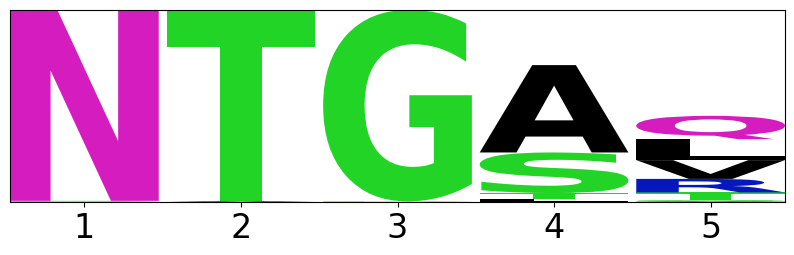

<Figure size 640x480 with 0 Axes>

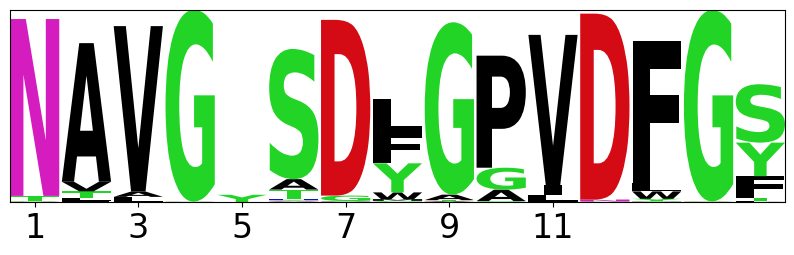

<Figure size 640x480 with 0 Axes>

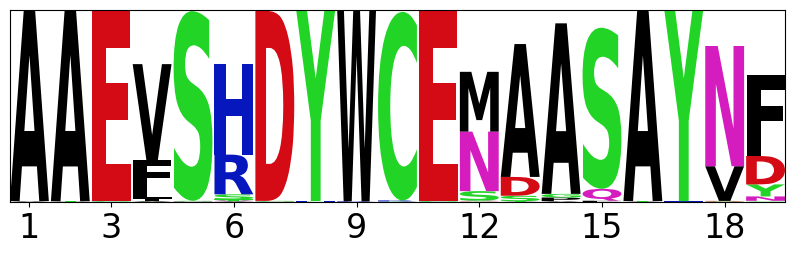

<Figure size 640x480 with 0 Axes>

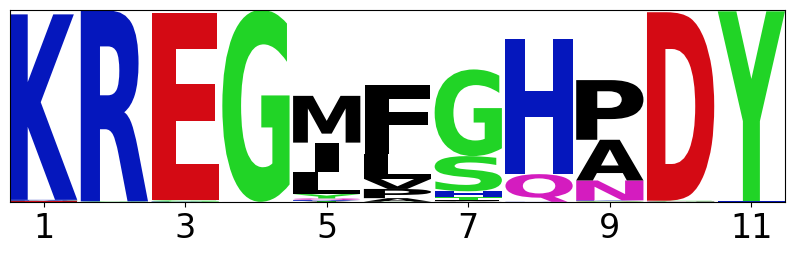

In [15]:
ticks = {
    411:np.array([1,2,3,4,5]),
    27:np.array([1,3,6,9,12,15,18]),
    0:np.array([1,3,5,7,9,11]),
    5:np.array([1,3,5,7,9,11])
}

aas = list('ACDEFGHIKLMNPQRSTVWY-')
for clone_id in [411, 0, 27, 5]:
    CDR3s = [cdr.strip() for cdr in open(f'{clone_id}_aligned.fasta','r').readlines()[1::2]]
    
    df = pd.DataFrame(index=range(len(CDR3s[0])),columns=aas)
    df.loc[:,:] = 0
    for cdr in CDR3s:
        for i,aa in enumerate(cdr):
            df.loc[i,aa] += 1
    df /= len(CDR3s)
    df = df.astype(float)
    del df['-']
    df = df[df.sum(axis=1)>0.001].reset_index(drop=True)
    
    entropy = -(df*np.log2(df+(1e-3/len(CDR3s)))).sum(axis=1)
    correction = 19/(np.log(2)*2*len(CDR3s))
    information = np.log2(20) - (entropy + correction)
    height = df.mul(information,axis='index')
    
    plt.figure()
    logomaker.Logo(height)
    plt.xticks(ticks[clone_id]-1,ticks[clone_id],fontsize=24)
    plt.yticks([])
    
    plt.savefig(f'{clone_id}_logo.png',dpi=300,bbox_inches='tight')